In [1]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
import time
import sympy as sp

In [2]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [17]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_cosine_term([2,-1,-1,0,0,0],indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    a_sat[i] = pham.state.particles[2].a
    e_sat[i] = pham.state.particles[2].e
    long_peri_sat[i] = pham.state.particles[2].pomega

e_f = pham.calculate_energy()
print('Final Energy: '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')

f_hy,pxx_hy = pomega_ft(times, long_peri_sat, e_sat)

Initial Energy: -0.00010494203027936993


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:54<00:00, 1838.28it/s]

Final Energy: -0.000104942029858784
Energy Percent Change: 4.007792952407854e-07 %


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 1st Order 2:1')

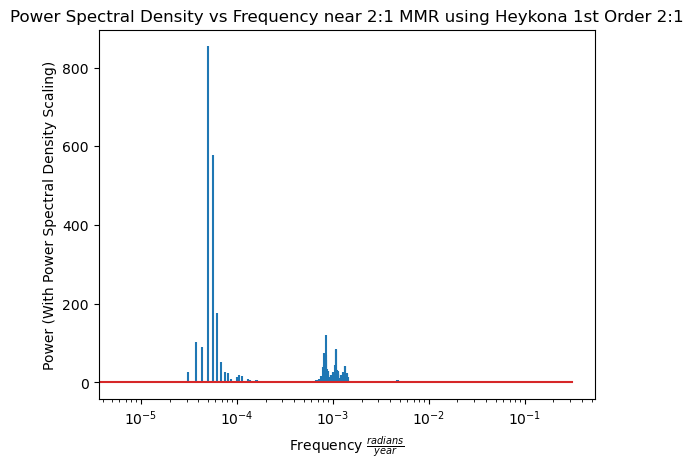

In [18]:
plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 1st Order 2:1')